In [61]:
import requests
import pandas as pd
import time
import os

locations = {

    # ACEH
    "Simeulue": (2.6167, 96.0833),
    "Aceh Singkil": (2.2875, 97.7889),

    # SUMATERA UTARA
    "Nias": (1.0333, 97.7667),
    "Nias Selatan": (0.5833, 97.8333),
    "Nias Barat": (1.0000, 97.5000),
    "Nias Utara": (1.2500, 97.6000),

    # SUMATERA BARAT
    "Kepulauan Mentawai": (-2.1333, 99.5000),

    # KEPULAUAN RIAU
    "Natuna": (3.9500, 108.3833),
    "Kepulauan Anambas": (3.1053, 106.6206),

    # KALIMANTAN BARAT
    "Kapuas Hulu": (0.8333, 112.9333),

    # KALIMANTAN TIMUR
    "Mahakam Ulu": (0.5000, 115.5000),

    # KALIMANTAN UTARA
    "Malinau": (3.5844, 116.6478),
    "Nunukan": (4.1333, 117.6667),

    # SULAWESI UTARA
    "Kepulauan Sangihe": (3.5000, 125.5000),
    "Kepulauan Talaud": (4.2500, 126.7833),

    # SULAWESI TENGAH
    "Tojo Una-Una": (-1.2167, 121.4833),

    # SULAWESI TENGGARA
    "Wakatobi": (-5.3167, 123.5500),

    # NUSA TENGGARA TIMUR
    "Sumba Barat": (-9.5333, 119.3667),
    "Sumba Tengah": (-9.4167, 119.6333),
    "Sumba Barat Daya": (-9.5667, 119.0500),
    "Sumba Timur": (-9.6500, 120.2667),
    "Alor": (-8.3000, 124.5667),
    "Lembata": (-8.3833, 123.4000),
    "Rote Ndao": (-10.7333, 123.0667),
    "Sabu Raijua": (-10.5000, 121.8333),
    "Timor Tengah Selatan": (-9.8500, 124.2833),
    "Timor Tengah Utara": (-9.4333, 124.4833),
    "Belu": (-9.0167, 124.9500),
    "Malaka": (-9.5667, 124.9000),

    # MALUKU
    "Maluku Barat Daya": (-7.5000, 126.0000),
    "Kepulauan Aru": (-6.1947, 134.5500),
    "Seram Bagian Timur": (-3.0000, 130.0000),
    "Buru Selatan": (-3.7000, 126.7000),
    "Kepulauan Tanimbar": (-7.9667, 131.3000),

    # MALUKU UTARA
    "Pulau Morotai": (2.3333, 128.5000),

    # PAPUA SELATAN
    "Merauke": (-8.4932, 140.4018),
    "Mappi": (-7.0000, 139.0000),
    "Asmat": (-5.0833, 138.0833),
    "Boven Digoel": (-6.1000, 140.3000),

    # PAPUA PEGUNUNGAN
    "Jayawijaya": (-4.0833, 138.9500),
    "Yahukimo": (-4.0833, 139.5000),
    "Pegunungan Bintang": (-4.5000, 140.4000),
    "Tolikara": (-3.4833, 138.4667),
    "Lanny Jaya": (-3.9167, 138.4167),
    "Nduga": (-4.4000, 138.1000),
    "Mamberamo Tengah": (-3.6167, 138.3000),
    "Yalimo": (-3.7167, 139.5833),

    # PAPUA TENGAH
    "Puncak": (-3.9833, 137.6333),
    "Puncak Jaya": (-3.7000, 137.0000),
    "Mimika": (-4.5470, 136.8874),
    "Dogiyai": (-4.0167, 135.7500),
    "Deiyai": (-4.0833, 136.0833),
    "Intan Jaya": (-3.5000, 136.7000),

    # PAPUA
    "Waropen": (-2.3000, 136.6000),
    "Mamberamo Raya": (-2.5333, 137.9667),
    "Supiori": (-0.7500, 135.6333),

    # PAPUA BARAT DAYA
    "Tambrauw": (-0.7500, 132.0833),
    "Maybrat": (-1.3333, 132.2500),
    "Raja Ampat": (-0.2333, 130.5167),
}

# LIST PENAMPUNG DATA
all_data = []

# LOOP SETIAP KOTA
for city, (lat, lon) in locations.items():

    print(f"Mengambil data {city}...")

    url = (
        f"https://re.jrc.ec.europa.eu/api/v5_2/seriescalc?"
        f"lat={lat}"
        f"&lon={lon}"
        f"&startyear=2015"
        f"&endyear=2020"
        f"&outputformat=json"
        f"&pvcalculation=1"
        f"&peakpower=1"
        f"&loss=14"
        f"&trackingtype=0"
        f"&optimalinclination=1"
        f"&optimalangles=1"
    )

    response = requests.get(url)

    if response.status_code != 200:
        print(f"Gagal mengambil data {city}. Status code: {response.status_code}. Response: {response.text}")
        continue

    data = response.json()

    try:
        hourly_data = data["outputs"]["hourly"]

        df_city = pd.DataFrame(hourly_data)

        df_city["City"] = city

        all_data.append(df_city)

        print(f"Berhasil: {city}")

    except Exception as e:
        print(f"Format data error pada {city}: {e}")

    time.sleep(1)

# GABUNG SEMUA DATA
if not all_data:
    print("Tidak ada data yang berhasil diambil dari API untuk digabungkan.")
else:
    df = pd.concat(all_data, ignore_index=True)

    # RENAME KOLOM
    df.rename(columns={
        "time": "Datetime",
        "G(i)": "SolarIrradiance",
        "H_sun": "SunHeight",
        "T2m": "Temperature",
        "WS10m": "WindSpeed",
        "P": "PowerOutput"
    }, inplace=True)

    # SIMPAN CSV
    filename = "pvgis_indonesia_energy.csv"

    df.to_csv(filename, index=False)

    # INFO DATASET
    print("\nDataset berhasil disimpan")
    print("Nama file:", filename)

    print("\nJumlah data:", len(df))
    print("Jumlah kolom:", len(df.columns))

    size_mb = os.path.getsize(filename) / (1024 * 1024)

    print(f"Ukuran file: {size_mb:.2f} MB")

    print("\n5 Data Pertama")
    print(df.head())

Mengambil data Simeulue...
Berhasil: Simeulue
Mengambil data Aceh Singkil...
Gagal mengambil data Aceh Singkil. Status code: 500. Response: {"message":"Internal Server Error","status":500}

Mengambil data Nias...
Berhasil: Nias
Mengambil data Nias Selatan...
Berhasil: Nias Selatan
Mengambil data Nias Barat...
Berhasil: Nias Barat
Mengambil data Nias Utara...
Berhasil: Nias Utara
Mengambil data Kepulauan Mentawai...
Gagal mengambil data Kepulauan Mentawai. Status code: 400. Response: {"message":"Location over the sea. Please, select another location","status":400}

Mengambil data Natuna...
Gagal mengambil data Natuna. Status code: 500. Response: {"message":"Internal Server Error","status":500}

Mengambil data Kepulauan Anambas...
Gagal mengambil data Kepulauan Anambas. Status code: 400. Response: {"message":"Location over the sea. Please, select another location","status":400}

Mengambil data Kapuas Hulu...
Gagal mengambil data Kapuas Hulu. Status code: 500. Response: {"message":"Intern

In [62]:
df

,Datetime,PowerOutput,SolarIrradiance,SunHeight,Temperature,WindSpeed,Int,City
0,20150101:0030,35.86,62.89,10.65,26.17,3.10,0.0,Simeulue
1,20150101:0130,108.00,153.56,24.20,26.48,3.24,0.0,Simeulue
2,20150101:0230,247.85,321.80,37.31,26.55,3.38,0.0,Simeulue
3,20150101:0330,281.46,363.02,49.43,26.98,3.17,0.0,Simeulue
4,20150101:0430,278.47,362.80,59.34,27.11,2.83,0.0,Simeulue
...,...,...,...,...,...,...,...,...
2209531,20201231:1930,0.00,0.00,0.00,22.54,0.34,0.0,Tambrauw
2209532,20201231:2030,0.00,0.00,0.00,22.85,0.00,0.0,Tambrauw
2209533,20201231:2130,3.51,13.55,3.85,22.48,0.41,0.0,Tambrauw
2209534,20201231:2230,3.51,13.55,17.61,22.76,0.55,0.0,Tambrauw


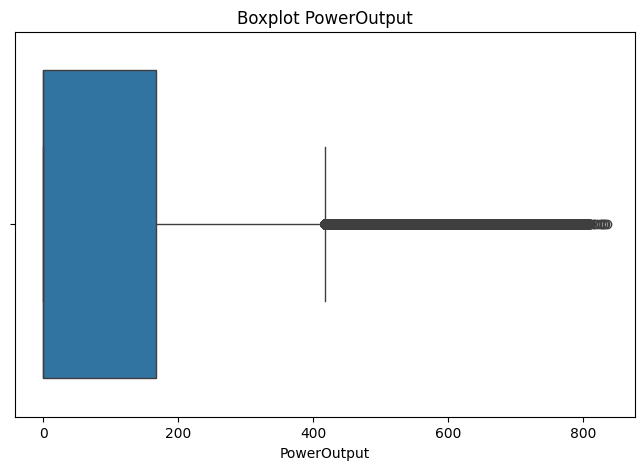

In [63]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(x=df['PowerOutput'])

plt.title('Boxplot PowerOutput')

plt.show()

In [64]:
# Hitung jumlah nilai 0
jumlah_nol = (df == 0).sum().sum()

# Total seluruh data
total_data = df.size

# Persentase sparsity
sparsity = (jumlah_nol / total_data) * 100

print(f"Sparsity: {sparsity:.2f}%")

Sparsity: 30.78%


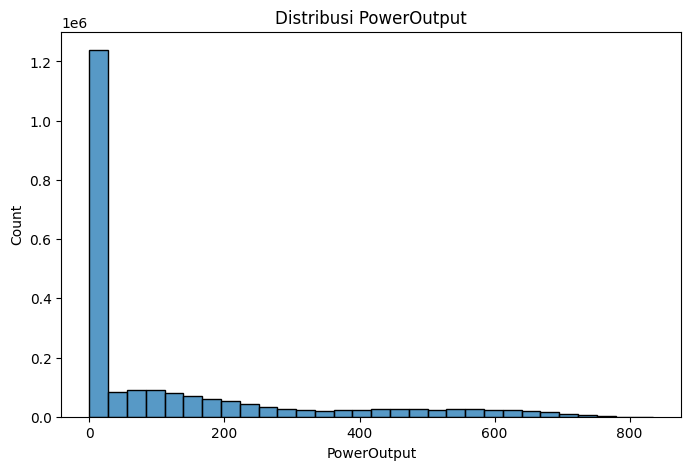

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(df['PowerOutput'], bins=30)

plt.title('Distribusi PowerOutput')

plt.show()

In [66]:
print(df['PowerOutput'].skew())

1.6754036076371488


# Pre Processing


In [67]:
import pandas as pd

# Membaca dataset CSV
df = pd.read_csv("pvgis_indonesia_energy.csv")

# Menampilkan 5 data pertama
print(df.head())

# Menampilkan jumlah baris dan kolom
print("Shape Dataset:", df.shape)

        Datetime  PowerOutput  SolarIrradiance  SunHeight  Temperature  \
0  20150101:0030        35.86            62.89      10.65        26.17   
1  20150101:0130       108.00           153.56      24.20        26.48   
2  20150101:0230       247.85           321.80      37.31        26.55   
3  20150101:0330       281.46           363.02      49.43        26.98   
4  20150101:0430       278.47           362.80      59.34        27.11   

   WindSpeed  Int      City  
0       3.10  0.0  Simeulue  
1       3.24  0.0  Simeulue  
2       3.38  0.0  Simeulue  
3       3.17  0.0  Simeulue  
4       2.83  0.0  Simeulue  
Shape Dataset: (2209536, 8)


In [68]:
# Melihat informasi dataset
print(df.info())

# Melihat tipe data tiap kolom
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209536 entries, 0 to 2209535
Data columns (total 8 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Datetime         object 
 1   PowerOutput      float64
 2   SolarIrradiance  float64
 3   SunHeight        float64
 4   Temperature      float64
 5   WindSpeed        float64
 6   Int              float64
 7   City             object 
dtypes: float64(6), object(2)
memory usage: 134.9+ MB
None
Datetime            object
PowerOutput        float64
SolarIrradiance    float64
SunHeight          float64
Temperature        float64
WindSpeed          float64
Int                float64
City                object
dtype: object


In [69]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2209536 entries, 0 to 2209535
Data columns (total 8 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Datetime         object 
 1   PowerOutput      float64
 2   SolarIrradiance  float64
 3   SunHeight        float64
 4   Temperature      float64
 5   WindSpeed        float64
 6   Int              float64
 7   City             object 
dtypes: float64(6), object(2)
memory usage: 134.9+ MB
None


In [70]:
print(df.dtypes)

Datetime            object
PowerOutput        float64
SolarIrradiance    float64
SunHeight          float64
Temperature        float64
WindSpeed          float64
Int                float64
City                object
dtype: object


In [71]:
# 4. MENGECEK MISSING VALUE DAN DUPLICATE DATA

# Mengecek missing value pada setiap kolom
print("Jumlah Missing Value:")
print(df.isnull().sum())

# MENGHAPUS MISSING VALUE
df = df.dropna()

print("\nShape setelah menghapus missing value:")
print(df.shape)

# MENGECEK DUPLICATE DATA
print("\nJumlah Duplicate Data:")
print(df.duplicated().sum())

# MENGHAPUS DUPLICATE DATA

df = df.drop_duplicates()

print("\nShape setelah menghapus duplicate:")
print(df.shape)

Jumlah Missing Value:
Datetime           0
PowerOutput        0
SolarIrradiance    0
SunHeight          0
Temperature        0
WindSpeed          0
Int                0
City               0
dtype: int64

Shape setelah menghapus missing value:
(2209536, 8)

Jumlah Duplicate Data:
0

Shape setelah menghapus duplicate:
(2209536, 8)


In [72]:
# Konversi kolom Datetime menjadi format datetime

df['Datetime'] = pd.to_datetime(
    df['Datetime'],
    format='%Y%m%d:%H%M'
)

# Cek hasil konversi
print(df[['Datetime']].head())

# Cek tipe data terbaru
print(df.dtypes)

             Datetime
0 2015-01-01 00:30:00
1 2015-01-01 01:30:00
2 2015-01-01 02:30:00
3 2015-01-01 03:30:00
4 2015-01-01 04:30:00
Datetime           datetime64[ns]
PowerOutput               float64
SolarIrradiance           float64
SunHeight                 float64
Temperature               float64
WindSpeed                 float64
Int                       float64
City                       object
dtype: object


In [73]:
# 5. SORTING DATA BERDASARKAN WAKTU

df = df.sort_values(by=['City', 'Datetime'])

# Reset index setelah sorting
df = df.reset_index(drop=True)

# Menampilkan 5 data pertama
print(df.head())

             Datetime  PowerOutput  SolarIrradiance  SunHeight  Temperature  \
0 2015-01-01 00:30:00        88.46           126.13      41.04        22.00   
1 2015-01-01 01:30:00       109.69           153.47      54.43        23.82   
2 2015-01-01 02:30:00       342.54           441.29      66.74        23.05   
3 2015-01-01 03:30:00       267.10           347.85      74.85        23.76   
4 2015-01-01 04:30:00       178.44           237.30      71.78        23.54   

   WindSpeed  Int  City  
0       0.83  0.0  Alor  
1       0.97  0.0  Alor  
2       1.10  0.0  Alor  
3       1.31  0.0  Alor  
4       1.59  0.0  Alor  


In [74]:
# AGGREGASI DATA HOURLY MENJADI HARIAN

# Membuat kolom Date (tanggal saja tanpa jam)
df['Date'] = df['Datetime'].dt.date

# AGGREGASI PER HARI

daily_df = df.groupby(['City', 'Date']).agg({

    # Rata-rata irradiance harian
    'SolarIrradiance': 'mean',

    # Rata-rata ketinggian matahari
    'SunHeight': 'mean',

    # Rata-rata temperatur
    'Temperature': 'mean',

    # Rata-rata kecepatan angin
    'WindSpeed': 'mean',

    # Total output daya harian
    'PowerOutput': 'sum'

}).reset_index()

# RENAME KOLOM

daily_df.rename(columns={

    'SolarIrradiance': 'AvgSolarIrradiance',
    'SunHeight': 'AvgSunHeight',
    'Temperature': 'AvgTemperature',
    'WindSpeed': 'AvgWindSpeed',
    'PowerOutput': 'TotalPowerOutput'

}, inplace=True)

# MENAMPILKAN HASIL
print(daily_df.head())

print("\nShape Data Harian:")
print(daily_df.shape)

   City        Date  AvgSolarIrradiance  AvgSunHeight  AvgTemperature  \
0  Alor  2015-01-01           96.425000     21.650417       22.297500   
1  Alor  2015-01-02          119.814583     21.659583       22.083333   
2  Alor  2015-01-03          146.690000     21.670000       21.825000   
3  Alor  2015-01-04          191.933333     21.680833       22.907917   
4  Alor  2015-01-05          178.234583     21.694583       22.540000   

   AvgWindSpeed  TotalPowerOutput  
0      1.246667           1708.42  
1      1.787917           2176.00  
2      2.209167           2706.24  
3      2.077917           3534.78  
4      2.060000           3301.30  

Shape Data Harian:
(92064, 7)


Feature Engineering

In [77]:
# FEATURE ENGINEERING WAKTU
# DATA HARIAN

# Pastikan kolom Date bertipe datetime
daily_df['Date'] = pd.to_datetime(
    daily_df['Date']
)

# Mengambil tahun
daily_df['Year'] = daily_df['Date'].dt.year

# Mengambil bulan
daily_df['Month'] = daily_df['Date'].dt.month

# Mengambil hari
daily_df['Day'] = daily_df['Date'].dt.day

# MENAMPILKAN HASIL

print(
    daily_df[
        ['Date', 'Year', 'Month', 'Day']
    ].head()
)

        Date  Year  Month  Day
0 2015-01-01  2015      1    1
1 2015-01-02  2015      1    2
2 2015-01-03  2015      1    3
3 2015-01-04  2015      1    4
4 2015-01-05  2015      1    5


Nilai nol pada variabel PowerOutput dan SolarIrradiance tidak dihapus karena merepresentasikan kondisi aktual pada malam hari ketika panel surya tidak menerima radiasi matahari. Untuk mengurangi dominasi nilai nol, data hourly kemudian diagregasi menjadi data harian sehingga pola produksi energi harian dapat direpresentasikan dengan lebih baik.

Gunanya Aggregasi Harian

Tahap ini bertujuan untuk:
1. mengubah data hourly menjadi harian
2. mengurangi dominasi nilai nol malam
3. membuat target forecasting harian
4.  menyederhanakan pola time series
5. mempersiapkan lag feature dan modeling

In [79]:
# FEATURE TEMPORAL

# Pastikan data sudah terurut
daily_df = daily_df.sort_values(by=['City', 'Date'])

# LAG FEATURE

# Output daya 1 hari sebelumnya
daily_df['Power_Lag1'] = (
    daily_df.groupby('City')['TotalPowerOutput']
    .shift(1)
)

# Irradiance 1 hari sebelumnya
daily_df['Irradiance_Lag1'] = (
    daily_df.groupby('City')['AvgSolarIrradiance']
    .shift(1)
)

# ROLLING MEAN

# Rata-rata output 3 hari terakhir
daily_df['Power_Rolling3'] = (
    daily_df.groupby('City')['TotalPowerOutput']
    .transform(lambda x: x.rolling(window=3).mean())
)

# Rata-rata irradiance 3 hari terakhir
daily_df['Irradiance_Rolling3'] = (
    daily_df.groupby('City')['AvgSolarIrradiance']
    .transform(lambda x: x.rolling(window=3).mean())
)

# HAPUS NILAI NaN

daily_df = daily_df.dropna()

# MENAMPILKAN HASIL

print(daily_df.head())

print("\nShape setelah feature temporal:")
print(daily_df.shape)

   City       Date  AvgSolarIrradiance  AvgSunHeight  AvgTemperature  \
2  Alor 2015-01-03          146.690000     21.670000       21.825000   
3  Alor 2015-01-04          191.933333     21.680833       22.907917   
4  Alor 2015-01-05          178.234583     21.694583       22.540000   
5  Alor 2015-01-06          212.489583     21.707083       22.825417   
6  Alor 2015-01-07          231.065833     21.452083       23.652500   

   AvgWindSpeed  TotalPowerOutput  Year  Month  Day  Power_Lag1  \
2      2.209167           2706.24  2015      1    3     2176.00   
3      2.077917           3534.78  2015      1    4     2706.24   
4      2.060000           3301.30  2015      1    5     3534.78   
5      2.240833           3917.02  2015      1    6     3301.30   
6      2.430833           4244.10  2015      1    7     3917.02   

   Irradiance_Lag1  Power_Rolling3  Irradiance_Rolling3  
2       119.814583     2196.886667           120.976528  
3       146.690000     2805.673333           152

jumlah data berkurang sedikit,
karena dropna() menghapus baris awal yang belum punya lag/rolling.

In [80]:
# MENENTUKAN FEATURE DAN TARGET

features = [

    'AvgSolarIrradiance',
    'AvgSunHeight',
    'AvgTemperature',
    'AvgWindSpeed',
    'Power_Lag1',
    'Irradiance_Lag1',
    'Power_Rolling3',
    'Irradiance_Rolling3'

]

target = 'TotalPowerOutput'

# MEMISAHKAN INPUT DAN TARGET

X = daily_df[features]

y = daily_df[target]

# MENAMPILKAN HASIL

print("Feature Input:")
print(X.head())

print("\nTarget:")
print(y.head())

Feature Input:
   AvgSolarIrradiance  AvgSunHeight  AvgTemperature  AvgWindSpeed  Power_Lag1  \
2          146.690000     21.670000       21.825000      2.209167     2176.00   
3          191.933333     21.680833       22.907917      2.077917     2706.24   
4          178.234583     21.694583       22.540000      2.060000     3534.78   
5          212.489583     21.707083       22.825417      2.240833     3301.30   
6          231.065833     21.452083       23.652500      2.430833     3917.02   

   Irradiance_Lag1  Power_Rolling3  Irradiance_Rolling3  
2       119.814583     2196.886667           120.976528  
3       146.690000     2805.673333           152.812639  
4       191.933333     3180.773333           172.285972  
5       178.234583     3584.366667           194.219167  
6       212.489583     3820.806667           207.263333  

Target:
2    2706.24
3    3534.78
4    3301.30
5    3917.02
6    4244.10
Name: TotalPowerOutput, dtype: float64


In [83]:
# TRAIN TEST SPLIT TIME SERIES

import pandas as pd

# Pastikan kolom Date bertipe datetime
daily_df['Date'] = pd.to_datetime(
    daily_df['Date']
)

# Batas split
split_date = pd.to_datetime('2020-01-01')

# MEMBAGI DATA TRAIN DAN TEST

# Data training
train_df = daily_df[
    daily_df['Date'] < split_date
]

# Data testing
test_df = daily_df[
    daily_df['Date'] >= split_date
]

# FEATURE DAN TARGET

features = [

    'AvgSolarIrradiance',
    'AvgSunHeight',
    'AvgTemperature',
    'AvgWindSpeed',
    'Power_Lag1',
    'Irradiance_Lag1',
    'Power_Rolling3',
    'Irradiance_Rolling3'

]

target = 'TotalPowerOutput'

# MEMISAHKAN INPUT DAN TARGET

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

# HASIL

print("Train Shape:", X_train.shape)

print("Test Shape:", X_test.shape)

Train Shape: (76608, 8)
Test Shape: (15372, 8)


In [84]:
from sklearn.preprocessing import MinMaxScaler

# SCALER FEATURE

scaler_X = MinMaxScaler()

X_train_scaled = scaler_X.fit_transform(X_train)

X_test_scaled = scaler_X.transform(X_test)

# SCALER TARGET

scaler_y = MinMaxScaler()

y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1,1)
)

y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1,1)
)

In [122]:
import numpy as np

# FUNCTION MEMBUAT SEQUENCE

def create_sequences(X, y, time_steps=7):

    Xs = []
    ys = []

    for i in range(len(X) - time_steps):

        v = X[i:(i + time_steps)]

        Xs.append(v)

        ys.append(y[i + time_steps])

    return np.array(Xs), np.array(ys)

In [123]:
TIME_STEPS = 7

X_train_lstm, y_train_lstm = create_sequences(

    X_train_scaled,
    y_train_scaled,
    TIME_STEPS

)

X_test_lstm, y_test_lstm = create_sequences(

    X_test_scaled,
    y_test_scaled,
    TIME_STEPS

)

In [124]:
print(X_train_lstm.shape)

print(y_train_lstm.shape)

print(X_test_lstm.shape)

print(y_test_lstm.shape)

(76601, 7, 8)
(76601, 1)
(15365, 7, 8)
(15365, 1)


# Random Forest Regression


In [99]:
# RANDOM FOREST REGRESSION

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# MEMBUAT MODEL
rf_model = RandomForestRegressor(

    n_estimators=100,
    random_state=42

)

# TRAINING MODEL

rf_model.fit(X_train, y_train)

# PREDIKSI

rf_pred = rf_model.predict(X_test)

# EVALUASI MODEL

mae_rf = mean_absolute_error(y_test, rf_pred)

mse_rf = mean_squared_error(y_test, rf_pred)

rmse_rf = mse_rf ** 0.5

r2_rf = r2_score(y_test, rf_pred)

# HASIL
print("Random Forest Regression")

print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Regression
MAE : 15.0669093871975
MSE : 539.4395425907478
RMSE: 23.225837823224975
R2 Score: 0.9997580313882234


In [100]:
# XGBOOST REGRESSION

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# MEMBUAT MODEL XGBOOST

xgb_model = XGBRegressor(

    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42

)

# TRAINING MODEL

xgb_model.fit(X_train, y_train)

# PREDIKSI

xgb_pred = xgb_model.predict(X_test)

# EVALUASI MODEL

mae_xgb = mean_absolute_error(y_test, xgb_pred)

mse_xgb = mean_squared_error(y_test, xgb_pred)

rmse_xgb = mse_xgb ** 0.5

r2_xgb = r2_score(y_test, xgb_pred)

# HASIL EVALUASI

print("XGBoost Regression")

print("MAE :", mae_xgb)

print("MSE :", mse_xgb)

print("RMSE:", rmse_xgb)

print("R2 Score:", r2_xgb)

XGBoost Regression
MAE : 15.023656337955426
MSE : 496.7013145295578
RMSE: 22.286796865623327
R2 Score: 0.9997772018584935


# **LSTM**

In [125]:

# MEMBUAT MODEL LSTM

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

# Model Sequential
model_lstm = Sequential()

# Layer LSTM
model_lstm.add(

    LSTM(

        units=64,

        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )

    )

)

# Dropout
model_lstm.add(
    Dropout(0.2)
)

# Output Layer
model_lstm.add(
    Dense(1)
)

# COMPILE MODEL

model_lstm.compile(

    optimizer='adam',

    loss='mse'

)

# MELIHAT ARSITEKTUR MODEL

model_lstm.summary()

# TRAINING MODEL

history = model_lstm.fit(

    X_train_lstm,
    y_train_lstm,

    epochs=20,

    batch_size=32,

    validation_data=(
        X_test_lstm,
        y_test_lstm
    ),

    verbose=1

)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,753 (73.25 KB)

 Trainable params: 18,753 (73.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - loss: 0.0098 - val_loss: 0.0088
Epoch 2/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 24s 8ms/step - loss: 0.0083 - val_loss: 0.0088
Epoch 3/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - loss: 0.0080 - val_loss: 0.0087
Epoch 4/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0079 - val_loss: 0.0090
Epoch 5/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0078 - val_loss: 0.0091
Epoch 6/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0077 - val_loss: 0.0087
Epoch 7/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0076 - val_loss: 0.0087
Epoch 8/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0075 - val_loss: 0.0084
Epoch 9/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0075 - val_loss: 0.0087
Epoch 10/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.0075 - val_loss: 0.0084
Epoch 11/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - loss: 0.0075 - val_loss: 0.0085
Epoch 12/20
2394/23

In [126]:
# PREDIKSI LSTM

y_pred_lstm = model_lstm.predict(
    X_test_lstm
)

# CEK SHAPE

print(y_pred_lstm.shape)

print(y_test_lstm.shape)

481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(15365, 1)
(15365, 1)


In [127]:
# PREDIKSI LSTM

y_pred_lstm = model_lstm.predict(X_test_lstm)

# INVERSE TRANSFORM

y_pred_lstm_inverse = scaler_y.inverse_transform(
    y_pred_lstm
)

y_test_inverse = scaler_y.inverse_transform(
    y_test_lstm
)

# EVALUASI MODEL

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae_lstm = mean_absolute_error(
    y_test_inverse,
    y_pred_lstm_inverse
)

mse_lstm = mean_squared_error(
    y_test_inverse,
    y_pred_lstm_inverse
)

rmse_lstm = mse_lstm ** 0.5

r2_lstm = r2_score(
    y_test_inverse,
    y_pred_lstm_inverse
)

# HASIL EVALUASI

print("LSTM Evaluation")

print("MAE :", mae_lstm)

print("MSE :", mse_lstm)

print("RMSE:", rmse_lstm)

print("R2 Score:", r2_lstm)

481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
LSTM Evaluation
MAE : 375.3758663933478
MSE : 297574.92692570837
RMSE: 545.50428680782
R2 Score: 0.8665676480147805


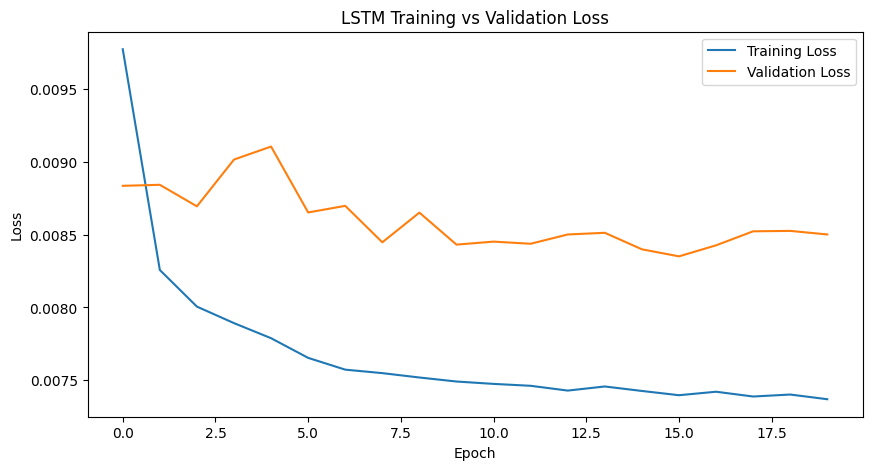

In [128]:
# VISUALISASI TRAINING DAN VALIDATION LOSS LSTM

import matplotlib.pyplot as plt

# Membuat ukuran grafik
plt.figure(figsize=(10,5))

# Grafik training loss
plt.plot(
    history.history['loss'],
    label='Training Loss'
)

# Grafik validation loss
plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

# Judul grafik
plt.title('LSTM Training vs Validation Loss')

# Label sumbu
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Legend
plt.legend()

# Menampilkan grafik
plt.show()

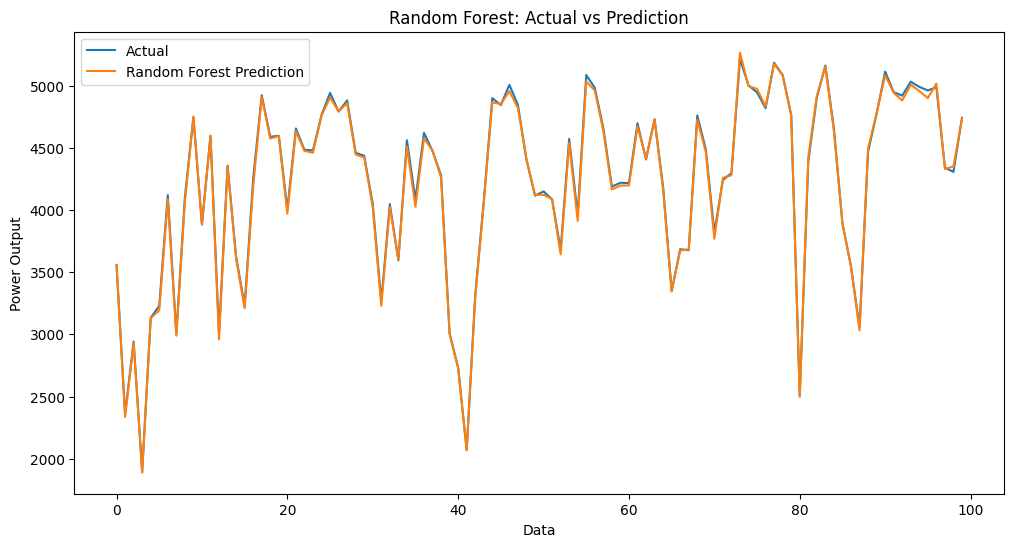

In [129]:
# VISUALISASI RANDOM FOREST
# ACTUAL VS PREDICTION

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Data aktual
plt.plot(

    y_test.values[:100],

    label='Actual'

)

# Hasil prediksi Random Forest
plt.plot(

    rf_pred[:100],

    label='Random Forest Prediction'

)

# Judul grafik
plt.title('Random Forest: Actual vs Prediction')

# Label sumbu
plt.xlabel('Data')

plt.ylabel('Power Output')

# Legend
plt.legend()

# Menampilkan grafik
plt.show()

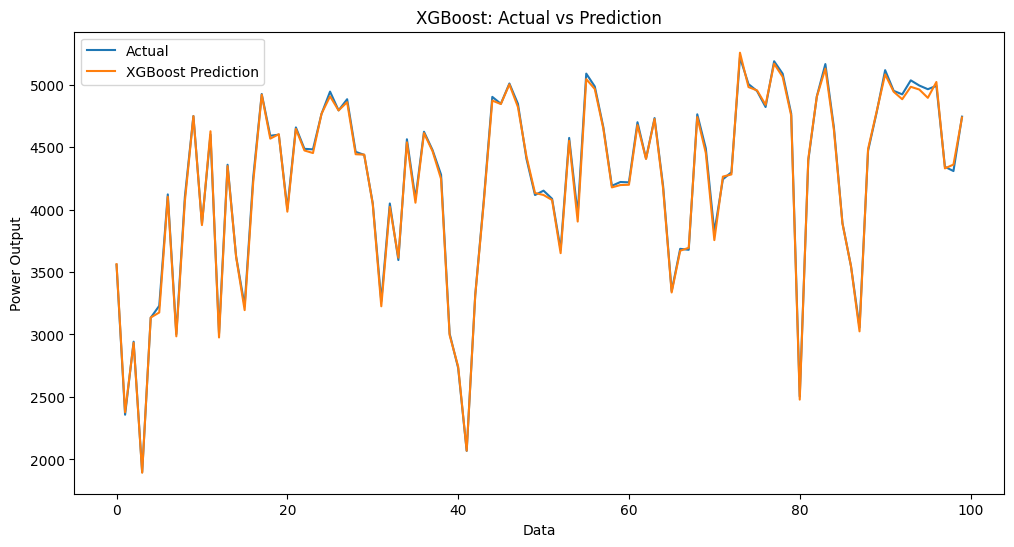

In [130]:
# VISUALISASI XGBOOST
# ACTUAL VS PREDICTION
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(

    y_test.values[:100],

    label='Actual'

)

plt.plot(

    xgb_pred[:100],

    label='XGBoost Prediction'

)

plt.title('XGBoost: Actual vs Prediction')
plt.xlabel('Data')
plt.ylabel('Power Output')
plt.legend()
plt.show()